In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import logging


import torch

logging.basicConfig(level=logging.INFO)

In [27]:
from brain_image.configs import get_device


cp_path = "logs/nice/version_38/checkpoints/nice-epoch=24-val_top1_acc=0.3790.ckpt"
device = get_device()
dtype = torch.float16


In [28]:
# To get the ground truth image embeddings, we need to use the image encoder from huggingface

from brain_image.reconstruction import ReconstructionPipeline


pipe = ReconstructionPipeline.from_stable_diffusion(dtype=dtype, device=device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error

In [29]:
import random
from typing import cast

from brain_image.model import NICEModel
from brain_image.prior import BrainDiffusionPrior, DiffusionPriorNetwork
from torch import Size
import tqdm

from PIL.Image import Image



logging.basicConfig(level=logging.INFO)

nice_model = NICEModel.load_checkpoint(cp_path, compile=False, preload_latents=False).to(device, dtype=dtype)


print(nice_model.config.project_dim)
target_latent_dim = 768

net = DiffusionPriorNetwork(
    dim=target_latent_dim,
    num_timesteps=1000,
    num_time_embeds=1,
    num_image_embeds=1,
    num_text_embeds=1,
    max_text_len=1,
    num_output_tokens=target_latent_dim,
    depth=6,
)
net.to(device, dtype=dtype)

prior = BrainDiffusionPrior(
    net=net,
    image_embed_dim=target_latent_dim,
    condition_on_text_encodings=False,
)

prior.eval()

prior.to(device, dtype=dtype)

768


BrainDiffusionPrior(
  (noise_scheduler): NoiseScheduler()
  (net): DiffusionPriorNetwork(
    (to_text_embeds): Sequential(
      (0): Identity()
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (to_time_embeds): Sequential(
      (0): Embedding(1000, 768)
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (to_image_embeds): Sequential(
      (0): Identity()
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (causal_transformer): CausalTransformer(
      (init_norm): Identity()
      (rel_pos_bias): RelPosBias(
        (relative_attention_bias): Embedding(32, 8)
      )
      (layers): ModuleList(
        (0-5): 6 x ModuleList(
          (0): Attention(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.0, inplace=False)
            (to_q): Linear(in_features=768, out_features=512, bias=False)
            (to_kv): Linear(in_features=768, out_features=128, bias=False)
            (rotary_emb): RotaryEmbedding()
            (to_out): Sequential(
        

In [30]:
from pathlib import Path
from brain_image.model import load_image_encoder


image_encoder = load_image_encoder("recon", "sd_highlevel", models_path=Path("models"), device=device, dtype=dtype)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error

In [ ]:
from pathlib import Path
from brain_image.data import TensorCache, load_image_from_path


batch_size = 4

loader = nice_model.data_module.test_dataloader()
ex_batch = next(iter(loader))
eeg_data = ex_batch["eeg_data"][:batch_size].to(device, dtype=dtype)
img_path = ex_batch["img_path"][:batch_size]

tensor_cache = TensorCache()

images = torch.stack([load_image_from_path(Path(p)) for p in img_path])[:batch_size].to(device)
target_img_latents = torch.stack([tensor_cache.get(str(p), "recon", "sd_highlevel", "test") for p in img_path]).to(device, dtype=dtype)


with torch.no_grad():    
    # Brain embed

    target_img_latents_temp = image_encoder(images)
    eeg_embed = nice_model.eeg_encoder(eeg_data)
    eeg_proj = nice_model.eeg_projector(eeg_embed).to(device)

    print("target_img_latents:", target_img_latents.shape, target_img_latents.dtype, target_img_latents.max(), target_img_latents.min())
    print("target_img_latents_temp:", target_img_latents_temp.shape, target_img_latents_temp.dtype, target_img_latents_temp.max(), target_img_latents_temp.min())
    print("eeg_proj:", eeg_proj.shape, eeg_proj.dtype, eeg_proj.max(), eeg_proj.min())

    prior_loss, prior_pred = prior.forward(brain_embedding=eeg_proj, image_embedding=target_img_latents)

    latent_reconstructed = pipe.reconstruct_latents(prior_pred)

target_img_latents: torch.Size([4, 768]) torch.float16 tensor(8.9609, device='cuda:0', dtype=torch.float16) tensor(-8.2891, device='cuda:0', dtype=torch.float16)
target_img_latents_temp: torch.Size([4, 768]) torch.float16 tensor(8.9609, dtype=torch.float16) tensor(-8.2891, dtype=torch.float16)
eeg_proj: torch.Size([4, 768]) torch.float16 tensor(38.5938, device='cuda:0', dtype=torch.float16) tensor(-33.2812, device='cuda:0', dtype=torch.float16)


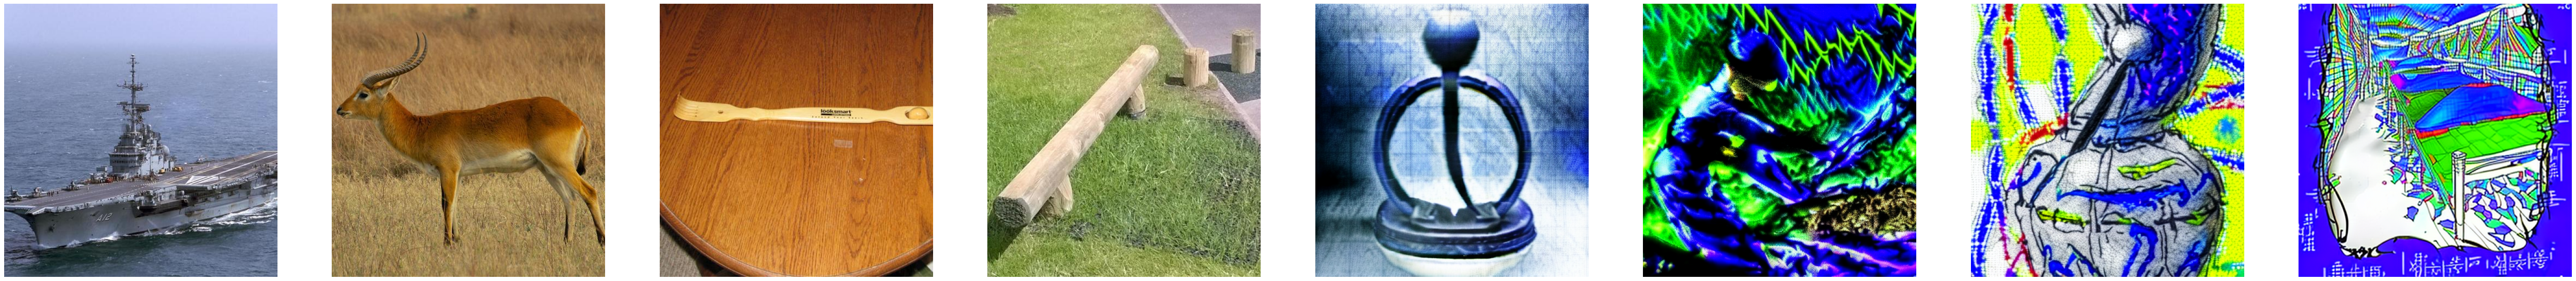

In [32]:
from brain_image.utils import show_image


show_image(images, latent_reconstructed, transforms=["normalize"] * batch_size + ["none"] * batch_size)

In [33]:
pipe.image_encoder

CLIPVisionModelWithProjection(
  (vision_model): CLIPVisionTransformer(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (position_embedding): Embedding(257, 1024)
    )
    (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-23): 24 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=1024, out_featur